In [11]:
%load_ext autoreload
%autoreload 2
import jax
import jax.numpy as jnp

from sklearn.datasets import make_s_curve, make_blobs
import sklearn

import matplotlib.pyplot as plt
import plotly.express as px

from jax.example_libraries import stax

import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO
from numpyro import optim
from numpyro.infer import Predictive
from numpyro import handlers



from numpyro.contrib.einstein import RBFKernel
from CustomModules.mixture_guide_impl_source import MixtureGuidePredictive
from CustomModules.stein_impl_source import SteinVI
from CustomModules.single_site_rbf import SingleSiteRBFKernel
from CustomModules.architectures import *



from morbius import make_mobius_strip
from checker import make_nd_checkerboard
rng_key = jax.random.key(42)

from CustomModules.normalizing_flow import normalizing_flow

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
def plot3d(d, title):
    d = d.reshape(-1, 3)
    fig = px.scatter_3d(x=d[:,0], y=d[:,1], z=d[:,2], title=title)
    fig.update_traces(marker=dict(size=2))


    fig.update_layout(
        title_text=title,
        title_x=0.5,              
        title_y=0.95,               
        title_font_family="Arial",  
        title_font_size=24,        
        title_font_color="navy",     
        margin=dict(t=60)            
    )

    fig.show()


In [13]:

X_3d_checkerboard = make_nd_checkerboard(2000, grid_shape=(4, 4, 1))[0]

plot3d(X_3d_checkerboard, "Checkerboard")

In [14]:
import numpy as np

n_samples = 2000

X_mobius, _  = make_mobius_strip(n_samples=2000, radius = 2, width = 3, noise=0.2)

plot3d(X_mobius, "Möbius Strip")

In [15]:
X_S, t = make_s_curve(noise=0.10, random_state=0, n_samples=1000)
plot3d(X_S, "Curve Data")

In [16]:
X_blobs, _=  make_blobs(centers=2,n_features=3, cluster_std=0.5, random_state=0, n_samples=1000)
plot3d(X_blobs, "Blob Data")

# Basic VAE

In [17]:

def encoder(hidden_dim, z_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.FanOut(2),
        stax.parallel(
            stax.Dense(z_dim, W_init=stax.randn()),
            stax.serial(stax.Dense(z_dim, W_init=stax.randn()), stax.Exp),
        ),
    )




def decoder(hidden_dim, out_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(out_dim, W_init=stax.randn()),
    )



def mean_network(hidden_dim, m_dim):
    SafeSoftplus = stax.elementwise(lambda x: jnp.log(1 + jnp.exp(x - 3.0)) + 1e-5)
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.FanOut(2),
        stax.parallel(
            stax.Dense(m_dim, W_init=stax.randn()),
            stax.serial(stax.Dense(m_dim, W_init=stax.randn()), SafeSoftplus),
        ),
    )



In [533]:
X = X_S

batch_size = X.shape[0]
dataloader = [X[i:i+batch_size] for i in range(0, len(X), batch_size)]

out_dim = X.reshape(X.shape[0], -1).shape[1]

hidden_dim = 8
z_dim = 2
lr=5e-3
adam = optim.Adam(lr)


encoder_args = {"hidden_dim": hidden_dim, "z_dim": z_dim}
decoder_args = {"hidden_dim": hidden_dim, "out_dim": out_dim}
mean_network_args = {"hidden_dim": hidden_dim, "m_dim": z_dim}

In [534]:
def plot_vae(vae, rng_key, share_axis=True):
    rng_key, e_sub, d_sub, s_sub = jax.random.split(rng_key, 4)

    values = vae.encode_batch(X, e_sub)
    X_recon = vae.decode_latent({"z": values["z"]}, d_sub)

    has_m = values.get("m") is not None
    c_recon = values.get("pidx")

    plot3d(X_recon["obs"], "recon")

    fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=share_axis, sharey=share_axis)

    for ax in axes.flat:
        ax.set_aspect('equal')

    axes[0, 0].scatter(values["z"][:, 0], values["z"][:, 1], c=c_recon)
    axes[0, 0].set_title("recon latent (z)")

    if has_m:
        axes[0, 1].scatter(values["m"][:, 0], values["m"][:, 1], c=c_recon)
        axes[0, 1].set_title("recon latent (m)")
    else:
        axes[0, 1].axis("off")

    values = vae.sample(s_sub, 1000)
    plot3d(values["obs"], "samples")

    c_samp = values.get("pidx")

    axes[1, 0].scatter(values["z"][:, 0], values["z"][:, 1], c=c_samp)
    axes[1, 0].set_title("samples latent (z)")

    if has_m:
        axes[1, 1].scatter(values["m"][:, 0], values["m"][:, 1], c=c_samp)
        axes[1, 1].set_title("samples latent (m)")
    else:
        axes[1, 1].axis("off")

    plt.tight_layout()
    plt.show()

# SMIVAE74

In [ ]:
def plot_smi_vae(vae, rng_key):
    rng_key, e_sub, d_sub, s_sub = jax.random.split(rng_key, 4)

    values = vae.encode_batch(X, e_sub)
    print(values)
    X_recon = vae.decode_latent({key:value  for key, value in values.items() if "z" in key}, d_sub, size_site="z0")

    plot3d(X_recon["obs"], "recon")


    values = vae.sample(s_sub, 1000)
    plot3d(values["obs"], "samples")


In [536]:
def f_shared(hidden_dim, f_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
    )

def g(z_dim):
    return stax.serial(
        stax.Dense(z_dim, W_init=stax.randn()),
    )

def h(hidden_dim, h_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
    )

In [537]:
rng_key, sub_key = jax.random.split(rng_key)
f_args = {"hidden_dim": hidden_dim, "f_dim": z_dim}
g_args = {"z_dim": z_dim}
h_args = {"hidden_dim": hidden_dim, "h_dim": z_dim}
flow_args = {"input_dim": z_dim, "hidden_dims": [5, 5], "steps": 10, "inv": True}
smivae74 = SMIVAE74(decoder, decoder_args, f_shared, f_args, h, h_args, g, g_args, g, g_args, 4, z_dim, normalizing_flow, flow_args)
smivae74.train(dataloader, len(X), adam, num_epochs=4000, rng_key=sub_key, num_stein_particles=5, annealing_epochs=1) # Annealing disabled

Epoch 3975, Loss: 3.54: 100%|██████████| 4000/4000 [01:45<00:00, 37.83it/s]  


In [538]:
rng_key, sub_key = jax.random.split(rng_key)
plot_smi_vae(smivae74, sub_key)

{'z3': Array([[ 0.58691573,  0.7499677 ],
       [-2.240298  ,  0.9957055 ],
       [ 1.5804149 ,  0.67003876],
       ...,
       [-3.5842936 ,  1.850071  ],
       [ 2.6922643 ,  0.26646414],
       [-1.8774955 ,  1.4716862 ]], dtype=float32), 'z2': Array([[-0.53288764,  0.41378257],
       [-2.7517796 ,  4.0608015 ],
       [ 0.38770562, -1.4549885 ],
       ...,
       [-5.1244283 ,  7.8984046 ],
       [ 2.5964713 , -2.0445752 ],
       [-1.5897628 ,  2.5525823 ]], dtype=float32), 'z1': Array([[ 0.1845327 ,  1.3805127 ],
       [-3.0755265 ,  4.8921394 ],
       [ 1.1874166 ,  0.03829093],
       ...,
       [-8.1095295 , 11.501507  ],
       [ 4.4379606 , -4.641042  ],
       [-2.6669786 ,  4.527213  ]], dtype=float32), 'z0': Array([[ 1.2435286 ,  1.3395351 ],
       [-6.132905  ,  5.8122497 ],
       [ 0.44743773,  0.06254017],
       ...,
       [-9.063312  , 13.36322   ],
       [ 7.3734765 , -3.839211  ],
       [-4.282914  ,  6.5862083 ]], dtype=float32), 'm': Array([[9.0840

# Post hoc model


In [154]:
rng_key, sub_key = jax.random.split(rng_key)
hoc_vae = PostHocSteinVAE(encoder, encoder_args, decoder, decoder_args, z_dim)

hoc_vae.train(dataloader, X.shape[0], adam, 6500, sub_key, num_stein_particles=8, post_hoc_epochs=5000)




100%|██████████| 5000/5000 [00:18<00:00, 271.79it/s]


In [155]:
hoc_vae.post_hoc_params["B"]

Array([[0.27444163, 0.29130736],
       [0.2740791 , 0.29038078],
       [0.27420437, 0.29209235],
       [0.27434018, 0.29187843],
       [0.2740406 , 0.29134125],
       [0.27449965, 0.29065335],
       [0.2749376 , 0.29012164],
       [0.27481842, 0.29103175]], dtype=float32)

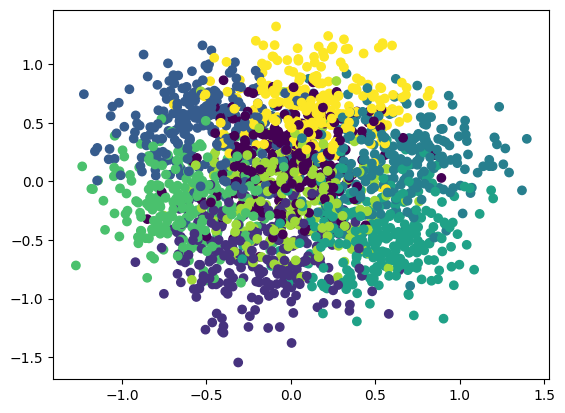

In [156]:
rng_key, sub_key = jax.random.split(rng_key)
results = hoc_vae.get_post_hoc_samples(sub_key, 2000)
plt.scatter(results["z"][:, 0], results["z"][:, 1], c=results.get("zidx"))

In [157]:
# decode resutls to see if they look good
decode_results=hoc_vae.decode_latent(results, sub_key)["obs"]
fig = px.scatter_3d(x=decode_results[:,0], y=decode_results[:,1], z=decode_results[:,2], title="decoded samples")
fig.update_traces(marker=dict(size=2))

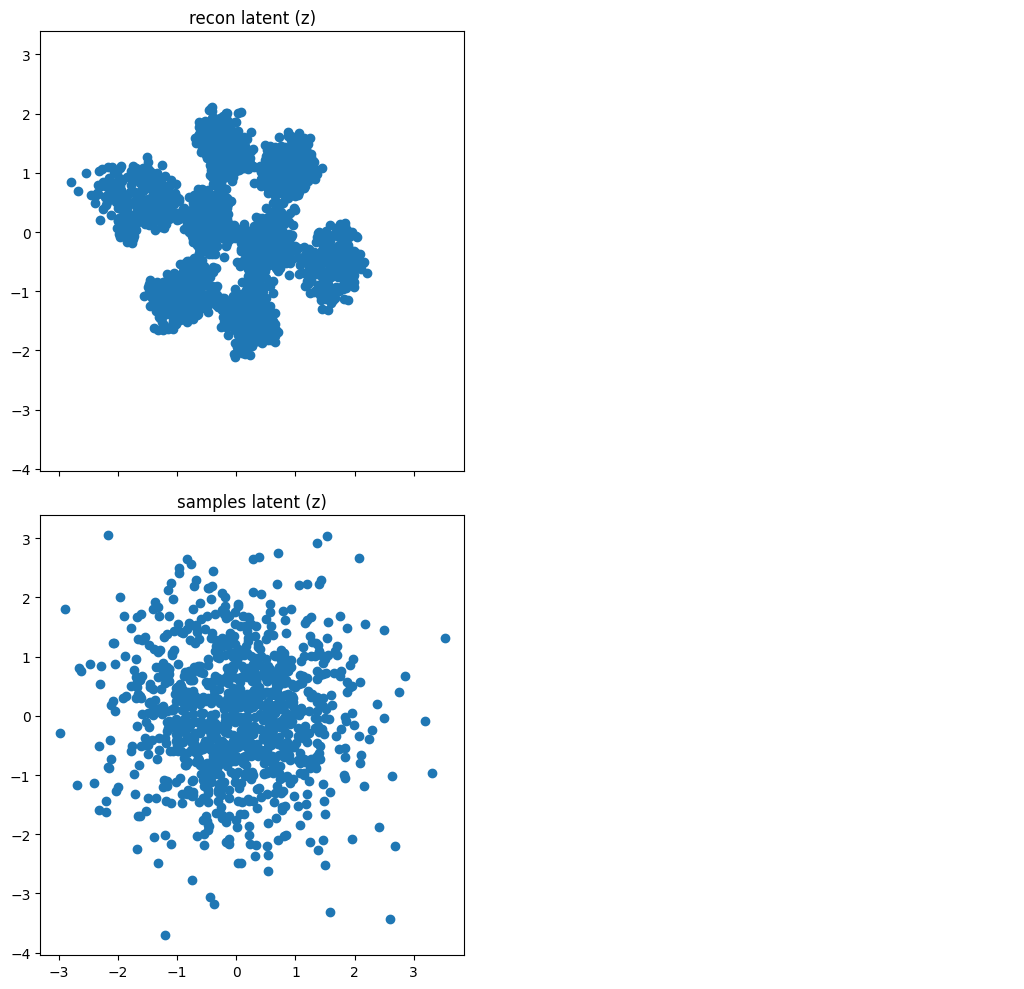

In [32]:
plot_vae(hoc_vae, sub_key)

# Just a model flow

In [54]:
rng_key, sub_key = jax.random.split(rng_key)
flow_args = {"input_dim": z_dim, "hidden_dims": [5, 5], "steps": 10, "inv": True}
base_vae = FlowBasicVAE(encoder, encoder_args, decoder, decoder_args, z_dim, normalizing_flow, flow_args)

base_vae.train(dataloader, X.shape[0], adam, 10000, sub_key, annealing_epochs=1000)




100%|██████████| 10000/10000 [01:05<00:00, 153.79it/s]


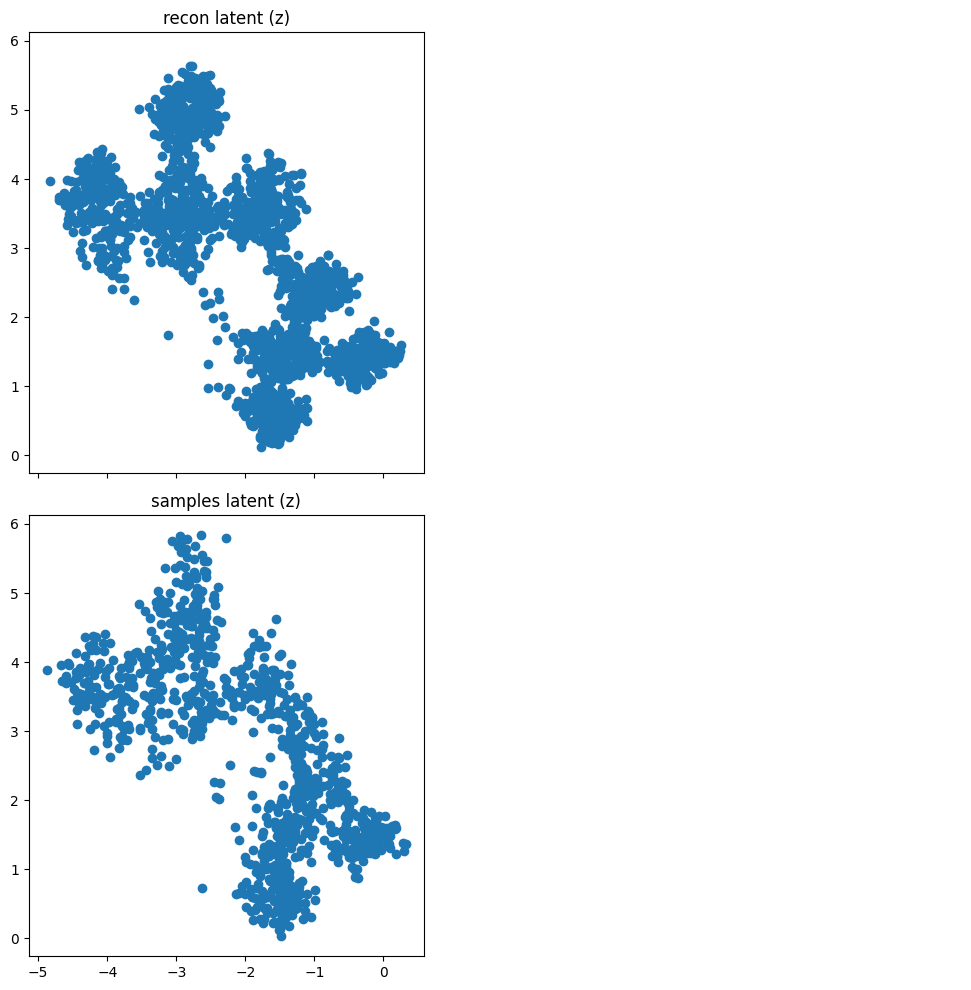

In [55]:
plot_vae(base_vae, sub_key)

# A global Parameter


In [44]:
rng_key, sub_key = jax.random.split(rng_key)

global_vae = GlobalVAE(encoder, encoder_args, decoder, decoder_args, z_dim)

global_vae.train(dataloader, X.shape[0], adam, 10000, sub_key)




100%|██████████| 10000/10000 [00:10<00:00, 978.46it/s]


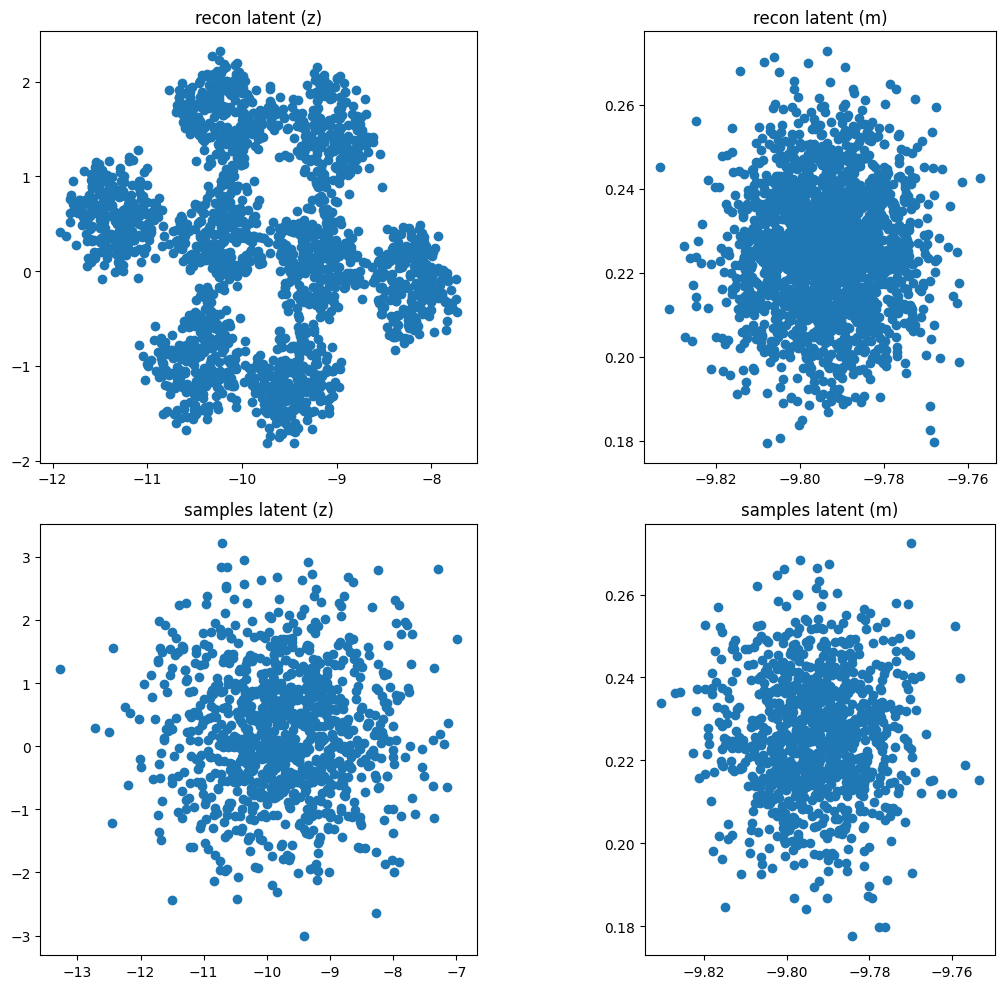

In [45]:
plot_vae(global_vae, sub_key, False)

# Stein global

In [46]:
rng_key, sub_key = jax.random.split(rng_key)

stein_global_vae = SteinGlobalVAE(encoder, encoder_args, decoder, decoder_args, z_dim)

stein_global_vae.train(dataloader, X.shape[0], adam, 10000, sub_key, 5, repulsion_temperature=1)




Epoch 9975, Loss: 45.18: 100%|██████████| 10000/10000 [00:42<00:00, 238.05it/s] 


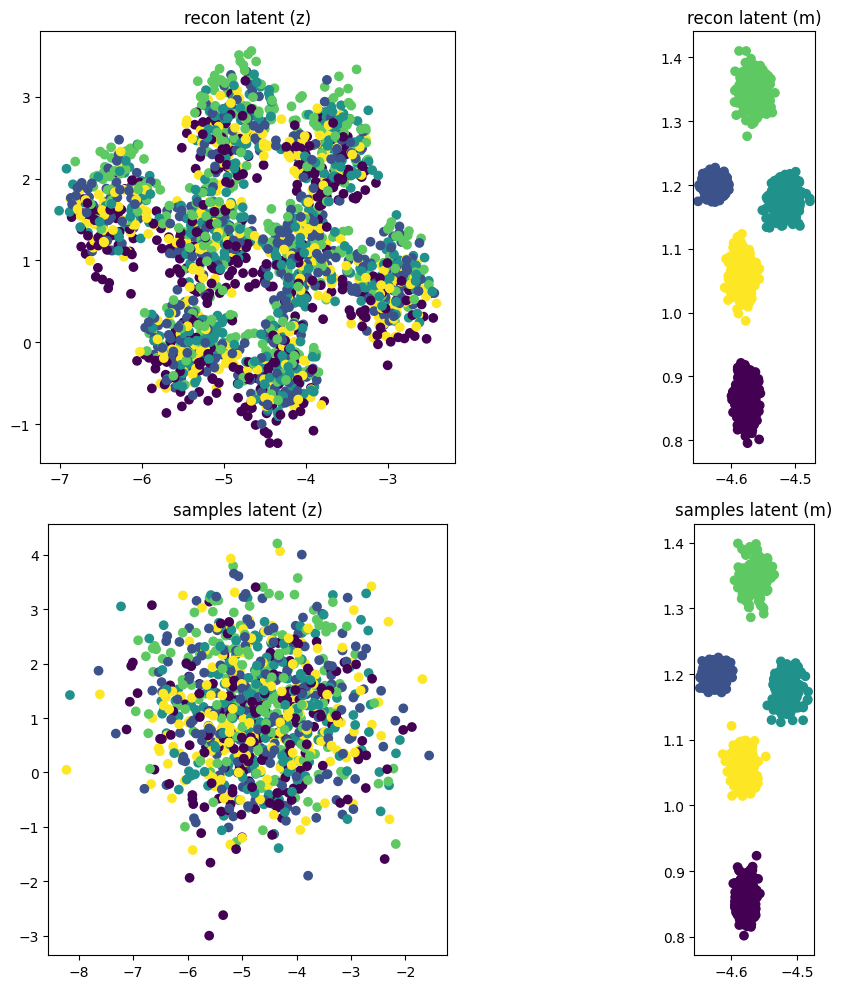

In [47]:
plot_vae(stein_global_vae, sub_key, False)

# Guide Flow


In [48]:
rng_key, sub_key = jax.random.split(rng_key)


flow_args = {"input_dim": z_dim, "hidden_dims": [2, 2], "steps": 10, "inv": True}

guide_flow_vae = GuideFlowGlobalVAE(encoder, encoder_args, decoder, decoder_args, z_dim, flow=normalizing_flow, flow_args=flow_args)

guide_flow_vae.train(dataloader, X.shape[0], adam, 10000, sub_key)



100%|██████████| 10000/10000 [00:24<00:00, 411.35it/s]


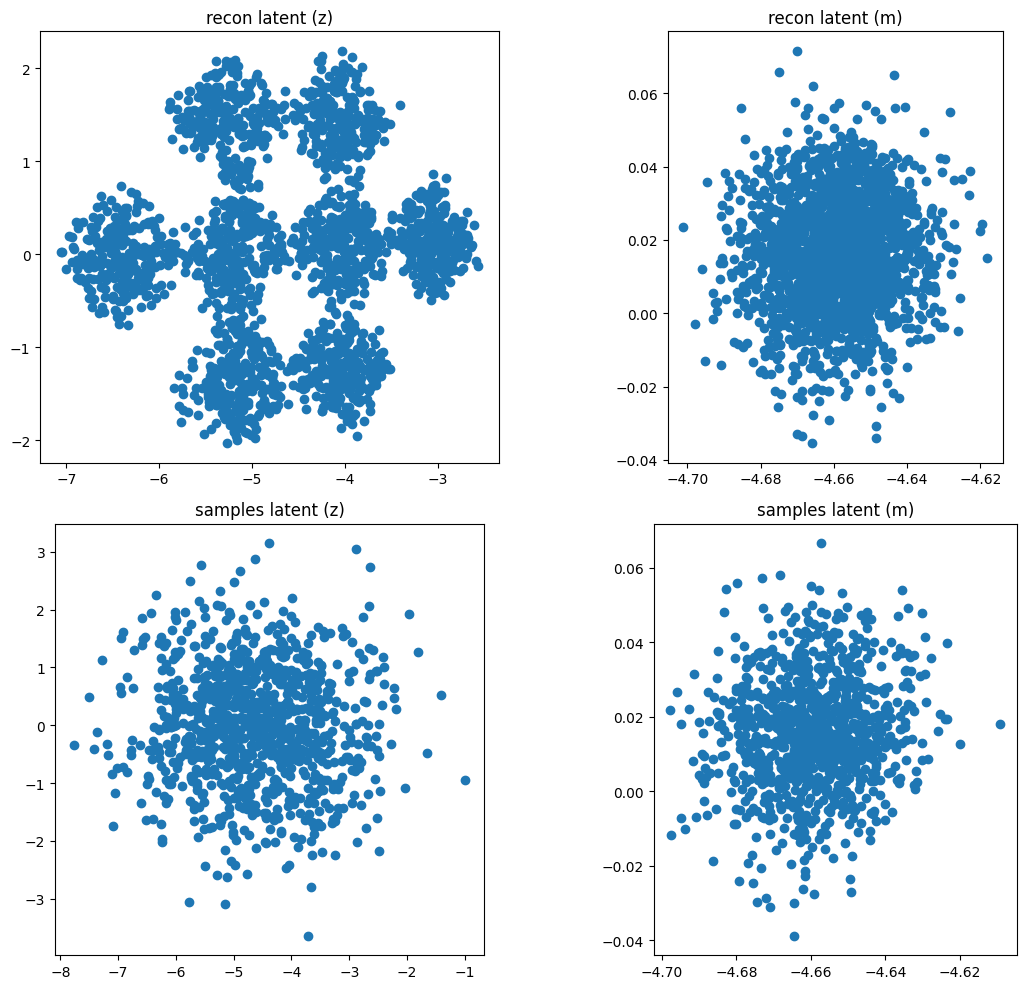

In [49]:
plot_vae(guide_flow_vae, sub_key, False)

# STEIN GUIDE FLOW

In [ ]:
rng_key, sub_key = jax.random.split(rng_key)
clipped_adam = optim.ClippedAdam(lr, 10)

flow_args = {"input_dim": z_dim, "hidden_dims": [2, 2], "steps": 5, "inv": True}

stein_guide_flow_vae = SteinGuideFlowVAE(encoder, encoder_args, decoder, decoder_args, z_dim, flow=normalizing_flow, flow_args=flow_args)

stein_guide_flow_vae.train(dataloader, X.shape[0], adam, 5000, sub_key, num_stein_particles=3, repulsion_temperature=1)



Epoch 4975, Loss: 8.97: 100%|██████████| 5000/5000 [00:51<00:00, 97.92it/s]   


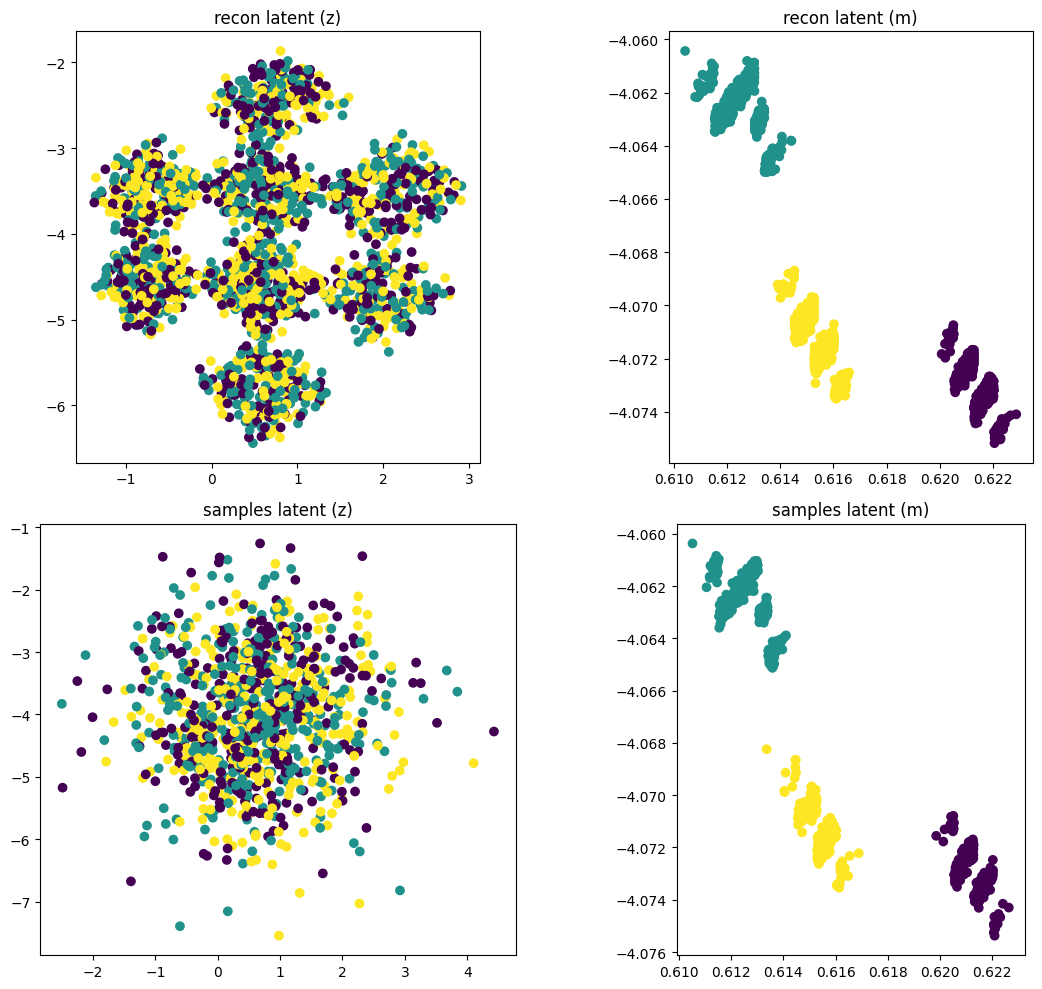

In [51]:
rng_key, sub_key = jax.random.split(rng_key)
plot_vae(stein_guide_flow_vae, sub_key, False)

# Learned Mean Stein

In [52]:
rng_key, sub_key = jax.random.split(rng_key)

flow_args = {"input_dim": z_dim, "hidden_dims": [2, 2], "steps": 5, "inv": True}

learned_mean_stein_guide_flow_vae = LearnedMeanSteinGuideFlowVAE(encoder, encoder_args, decoder, 
                                                    decoder_args, mean_network, mean_network_args, 
                                                    z_dim, flow=normalizing_flow, flow_args=flow_args)

learned_mean_stein_guide_flow_vae.train(dataloader, X.shape[0], optim.Adam(0.003), 6000, sub_key, num_stein_particles=3, repulsion_temperature=1, bandwidth_scaler=50)



Epoch 5975, Loss: 32.42: 100%|██████████| 6000/6000 [00:53<00:00, 112.05it/s]  


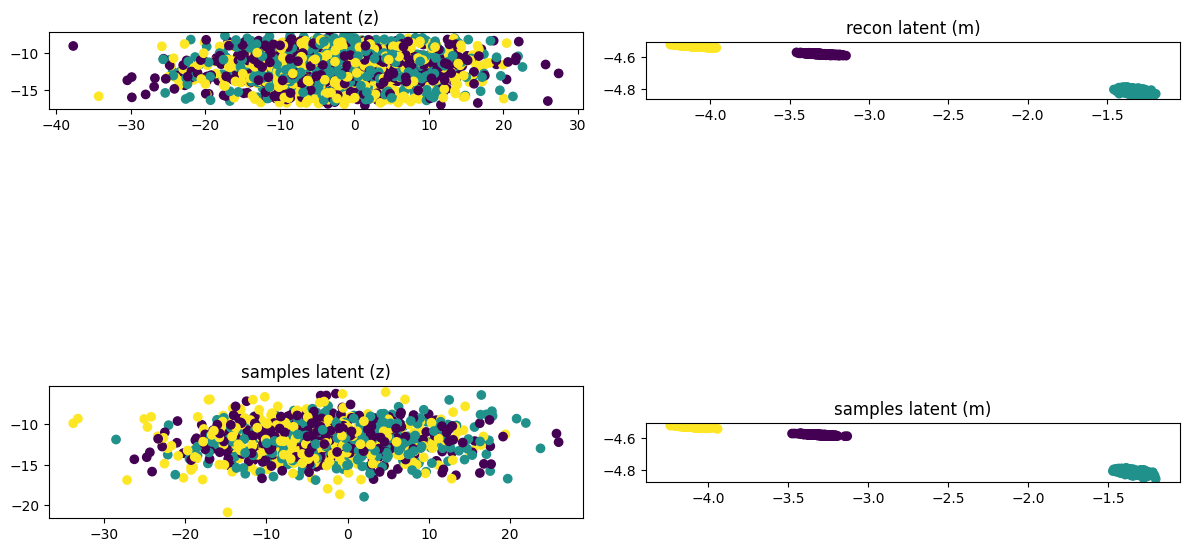

In [53]:
rng_key, sub_key = jax.random.split(rng_key)
plot_vae(learned_mean_stein_guide_flow_vae, sub_key, False)